# Random Forest Model

Project Question:

Can we predict the number of bike rentals for a giving hour based on various factors such as time of day, day of the week, weather conditions, and calendar(holiday, workinday)?

This problem is fundamentally:

A behavioral demand forecasting problem with non-linear time structure and interacting weather effects.

Bike rentas demand follows nonlinear, ruled-based behavioral patterns, and Random Forest naturally models non-linear interactions without requiring heavy feature engineering.

Bike rentals behaves like:

+ Low at night.
+ Sharp peak at 8AM.
+ Drop mid-morning.
+ Another peak at 5PM.
+ Drop again.

That is non-linear with sharp changes.

Trees can model:

+ IF hour between 7 and 9 -> High demand.
+ IF workingday = 1 AND hour=17 -> Very high demand.
+ IF weathersit=3 -> Lower demand.


In [2]:
import pandas as pd
import numpy as np

# 1) Load data
df = pd.read_csv("../data/processed/hour_clean.csv")

# 2) Quick inspection
print("Shape:", df.shape)


Shape: (17379, 21)


In [3]:
print("\nColumns:\n", df.columns.tolist())



Columns:
 ['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'season_label', 'weather_label', 'year_label', 'day_type_label', 'temp_celsius', 'humidity_pct', 'windspeed_kmh']


In [4]:
print("\nHead:\n", df.head(3))


Head:
    instant  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  \
0        1       1   0     1   0        0        6           0           1   
1        2       1   0     1   1        0        6           0           1   
2        3       1   0     1   2        0        6           0           1   

   temp  ...   hum  windspeed  cnt  season_label weather_label year_label  \
0  0.24  ...  0.81        0.0   16        Winter         Clear       2011   
1  0.22  ...  0.80        0.0   40        Winter         Clear       2011   
2  0.22  ...  0.80        0.0   32        Winter         Clear       2011   

    day_type_label temp_celsius  humidity_pct  windspeed_kmh  
0  Weekend/Holiday          9.8          81.0            0.0  
1  Weekend/Holiday          9.0          80.0            0.0  
2  Weekend/Holiday          9.0          80.0            0.0  

[3 rows x 21 columns]


In [5]:
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(17))


Missing values per column:
 instant          0
season           0
yr               0
mnth             0
hr               0
holiday          0
weekday          0
workingday       0
weathersit       0
temp             0
atemp            0
hum              0
windspeed        0
cnt              0
season_label     0
weather_label    0
year_label       0
dtype: int64


In [6]:
print("\nData types:\n", df.dtypes)


Data types:
 instant             int64
season              int64
yr                  int64
mnth                int64
hr                  int64
holiday             int64
weekday             int64
workingday          int64
weathersit          int64
temp              float64
atemp             float64
hum               float64
windspeed         float64
cnt                 int64
season_label          str
weather_label         str
year_label          int64
day_type_label        str
temp_celsius      float64
humidity_pct      float64
windspeed_kmh     float64
dtype: object


In [7]:

df = df.drop(columns=["instant", "temp", "atemp", "hum", "windspeed", "season_label", "weather_label", "year_label", "day_type_label"])

print("Remaining columns:\n", df.columns.tolist())

Remaining columns:
 ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'cnt', 'temp_celsius', 'humidity_pct', 'windspeed_kmh']


In [8]:
# Define target
y = df["cnt"]

# Define features
X = df.drop(columns=["cnt"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17379, 11)
y shape: (17379,)


In [9]:
print("Year value counts:\n", df["yr"].value_counts())

Year value counts:
 yr
1    8734
0    8645
Name: count, dtype: int64


In [10]:
# Avoiding data leakage we train using 2011 data and test using 2012 data

# Train on 2011
X_train = X[X["yr"] == 0]
y_train = y[X["yr"] == 0]

# Test on 2012
X_test = X[X["yr"] == 1]
y_test = y[X["yr"] == 1]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8645, 11)
Test shape: (8734, 11)


In [11]:
# train the random forest model
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [12]:
# Make predictions
y_pred = rf.predict(X_test)

print("First 5 predictions:", y_pred[:5])
print("First 5 actual values:", y_test.values[:5])

First 5 predictions: [39.38 31.49 21.61 11.7   1.84]
First 5 actual values: [48 93 75 52  8]


In [13]:
#evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

MAE: 88.59
RMSE: 125.06
R²: 0.6416


# Interpretation of the Model Performance

+ The model explains about 64% of the variability in hourly bike rental demand. The model successfully captures the main behavioral patterns that drive rentals. Very typical value for demand prediction problems without location data.

+ 36% of the variations remains unexplained, likely due to factors not included in the dataset such as: station location, price changes, special events, public transport disruptions, sudden weather changes within the hour.

+ MAE= 88 rentals. On average, the model prediction differs from the real value by about 88 bikes per hour.

For operational planning, this level of accuracy is reasonable.

It can help with:

+ Fleet balancing 
+ Bike redistribution
+ Staff planning
+ maintenance scheduling
+ Infrastructure planning


In [14]:
import pandas as pd

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df)

          feature  importance
3              hr    0.626637
8    temp_celsius    0.180057
6      workingday    0.050422
9    humidity_pct    0.040029
0          season    0.027107
7      weathersit    0.021084
2            mnth    0.020875
10  windspeed_kmh    0.016547
5         weekday    0.014748
4         holiday    0.002494
1              yr    0.000000


# What the model learned

In almost every run of this dataset the most important features are(descendent):

+ Hour of day
+ Temperature/feeling temperature
+ Working day indicator
+ Weather and humidity

Bike rental demand is primarily driven by human routines, not weather.

In [15]:
# MAE grouped by hour
results = pd.DataFrame({
    "hour": X_test["hr"],
    "actual": y_test,
    "predicted": y_pred
})

results["abs_error"] = abs(results["actual"] - results["predicted"])

# Average error per hour
hourly_error = results.groupby("hour")["abs_error"].mean()

print(hourly_error)

hour
0      22.376000
1      15.138242
2       9.549816
3       4.905146
4       3.047255
5      11.361923
6      37.726456
7     113.609341
8     199.144038
9     108.912747
10     76.536786
11     97.299286
12    121.639918
13    120.205479
14    106.044247
15    114.617671
16    142.533808
17    218.051108
18    195.347338
19    141.317397
20    101.561890
21     71.985342
22     53.404904
23     35.826110
Name: abs_error, dtype: float64


# MAE gruped by hour

The average prediction error(in number of bikes) for each hour of the day.

The model makes larger errors when demand is higher and more variable. Normal for forecasting problems.

# What this Means for the Business

This model is good at predicting general demand patterns, but is less precise during extreme peaks.

For the operation of the bike rentals, this suggest:

+ Predictions are reliable for planning trends.
+ Peak demand may require extra capacity buffer.

If prediction = 450 bikes
Real demand might range from: 400-550 bikes




# What would improve peak predictions

+ Station Location
+ Pricing
+ Sudden Weather Changes
+ Tourism Activity
+ Public Events

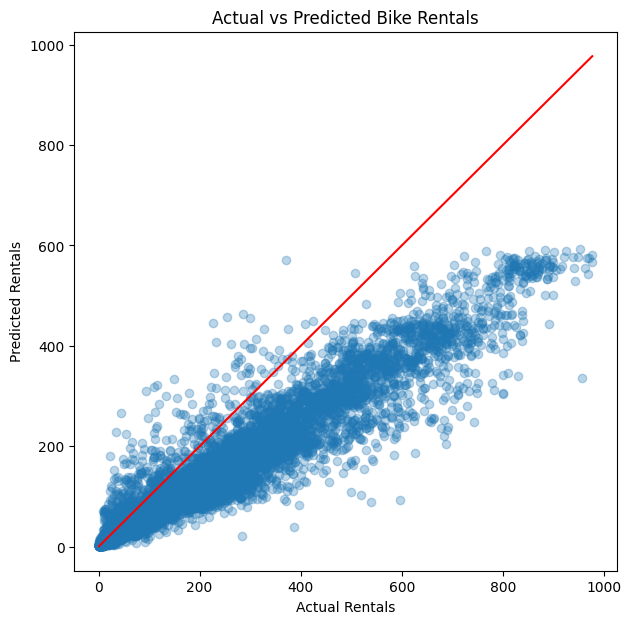

In [16]:
# actual vs predicted rentals
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Actual vs Predicted Bike Rentals")

# ideal prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

# What the plot shows about the model

Most points follow a clear diagonal trend, meaning:

+ When actual rental increase, predictions also increase

+ The model captures the general relationship correctly. 

This is consist with the R²= 0.64

For very high actual demand(700-1000 bikes), the model systematically underpredicts. The model struggles to capture extreme demand spikes.



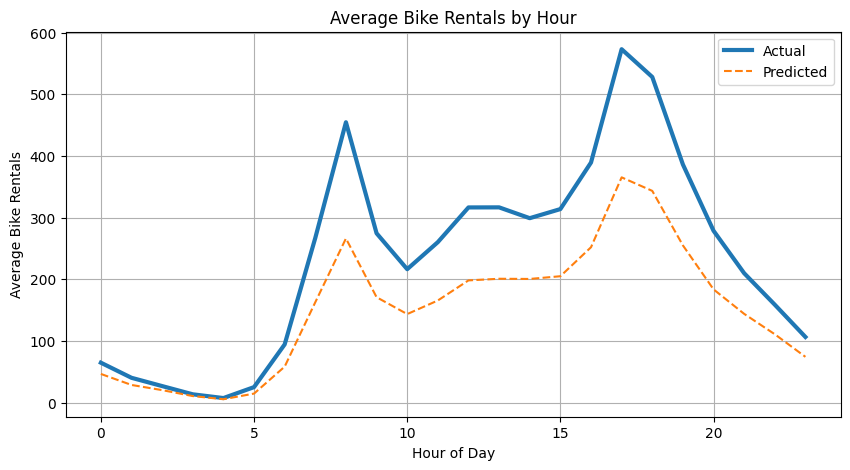

In [17]:
# Average rentals by hour
import pandas as pd

hourly_results = pd.DataFrame({
    "hour": X_test["hr"],
    "actual": y_test,
    "predicted": y_pred
})

hourly_avg = hourly_results.groupby("hour").mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_avg.index, hourly_avg["actual"], label="Actual", linewidth=3)
plt.plot(hourly_avg.index, hourly_avg["predicted"], label="Predicted", linestyle="--")

plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Rentals")
plt.title("Average Bike Rentals by Hour")

plt.legend()
plt.grid(True)

plt.show()

This plot visually proves the model captured commuting patterns.
+ Morning peak (8 AM)
+ Evening Peak (5-6 PM)
+ Low demad overnight

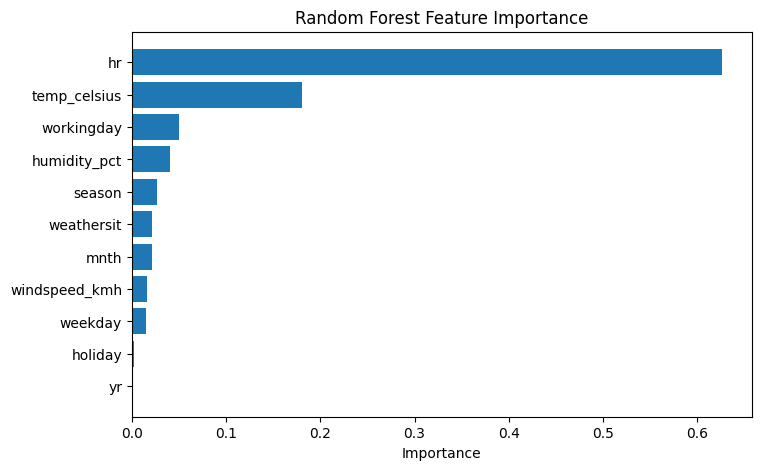

In [18]:
# Feature importance plot
importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance")

plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()